In [1]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Create a sample movie dataset
n_movies = 200

In [2]:
# Generate random data
titles = [f"Movie {i}" for i in range(1, n_movies + 1)]
years = np.random.randint(1990, 2023, n_movies)
genres = np.random.choice(['Action', 'Comedy', 'Drama', 'Sci-Fi', 'Horror', 'Thriller', 'Romance'], n_movies)
runtimes = np.random.randint(75, 180, n_movies)
budgets = np.round(np.random.uniform(5, 250, n_movies), 1)  # In millions USD
box_offices = np.round(budgets * np.random.uniform(0.5, 4, n_movies), 1)  # In millions USD

directors = []
for _ in range(n_movies):
    first_names = ['James', 'Steven', 'Christopher', 'Martin', 'Quentin', 'David', 'Ridley', 'Sofia', 'Greta', 'Kathryn']
    last_names = ['Smith', 'Johnson', 'Williams', 'Jones', 'Brown', 'Davis', 'Miller', 'Wilson', 'Moore', 'Taylor']
    directors.append(f"{np.random.choice(first_names)} {np.random.choice(last_names)}")

ratings = np.round(np.random.uniform(3, 9.5, n_movies), 1)
countries = np.random.choice(['USA', 'UK', 'France', 'Japan', 'South Korea', 'India', 'Canada', 'Germany'], n_movies)

In [3]:
# Create the DataFrame
movies_data = pd.DataFrame({
    'Title': titles,
    'Year': years,
    'Genre': genres,
    'Runtime': runtimes,
    'Budget': budgets,
    'BoxOffice': box_offices,
    'Director': directors,
    'Rating': ratings,
    'Country': countries
})

In [4]:
# Introduce some missing values
for col in ['Runtime', 'Budget', 'BoxOffice', 'Rating']:
    missing_indices = np.random.choice(n_movies, size=int(n_movies * 0.05), replace=False)
    movies_data.loc[missing_indices, col] = np.nan

# Display the DataFrame
print(movies_data.head())

     Title  Year     Genre  Runtime  Budget  BoxOffice      Director  Rating  \
0  Movie 1  2018    Sci-Fi     75.0   147.4      507.4  James Miller     5.2   
1  Movie 2  2004     Drama    108.0   216.5      175.8   James Jones     4.6   
2  Movie 3  1997    Action    170.0   220.7      523.9   Greta Smith     9.0   
3  Movie 4  2010    Sci-Fi    122.0    63.0       82.9  Martin Davis     3.7   
4  Movie 5  2008  Thriller    163.0   227.4      386.6  David Wilson     7.5   

   Country  
0   France  
1  Germany  
2      USA  
3    Japan  
4       UK  


In [ ]:
#Save to CSV
movies_data.to_csv('movies_data.csv', index=False)

### Task 1: Basic Data Exploration (Beginner)

In [16]:
#1. Read the CSV file
movies_data_from_csv = pd.read_csv('movies_data.csv')

#2. Display the first 5 rows of the DataFrame.
print(movies_data_from_csv.head())

     Title  Year     Genre  Runtime  Budget  BoxOffice      Director  Rating  \
0  Movie 1  2018    Sci-Fi     75.0   147.4      507.4  James Miller     5.2   
1  Movie 2  2004     Drama    108.0   216.5      175.8   James Jones     4.6   
2  Movie 3  1997    Action    170.0   220.7      523.9   Greta Smith     9.0   
3  Movie 4  2010    Sci-Fi    122.0    63.0       82.9  Martin Davis     3.7   
4  Movie 5  2008  Thriller    163.0   227.4      386.6  David Wilson     7.5   

   Country  
0   France  
1  Germany  
2      USA  
3    Japan  
4       UK  


In [17]:
#3. Show the shape of the DataFrame (rows and columns).
movies_data_from_csv.shape

(200, 9)

In [18]:
#4. Generate basic descriptive statistics for the numerical columns.
movies_data_from_csv.describe()

,Year,Runtime,Budget,BoxOffice,Rating
count,200.00000,190.000000,190.000000,190.000000,190.000000
mean,2005.99500,127.557895,125.166316,289.196842,6.337895
std,10.10224,31.736586,69.435439,218.797221,1.914892
min,1990.00000,75.000000,5.600000,8.800000,3.000000
25%,1997.00000,98.250000,67.575000,113.275000,4.525000
50%,2006.00000,126.000000,122.650000,222.250000,6.500000
75%,2015.00000,158.000000,186.300000,462.575000,8.000000
max,2022.00000,179.000000,249.000000,927.800000,9.400000


In [20]:
#5. Check for missing values in each column.
movies_data_from_csv.isna().sum()

Title         0
Year          0
Genre         0
Runtime      10
Budget       10
BoxOffice    10
Director      0
Rating       10
Country       0
dtype: int64

### Task 2: Data Filtering and Selection (Intermediate)

In [25]:
#1. Select all movies released after 2010.
new_movies_data = movies_data_from_csv[movies_data_from_csv["Year"]>2020]
print(new_movies_data)

         Title  Year     Genre  Runtime  Budget  BoxOffice  \
17    Movie 18  2022  Thriller    100.0   186.5      489.8   
75    Movie 76  2022  Thriller    141.0   195.5      608.2   
82    Movie 83  2022   Romance    103.0   144.4      436.9   
100  Movie 101  2021    Comedy      NaN     NaN      133.3   
101  Movie 102  2021   Romance    132.0   220.2      448.2   
108  Movie 109  2021    Action     84.0   208.7      500.9   
121  Movie 122  2022    Comedy     97.0   156.2      503.7   
130  Movie 131  2022    Sci-Fi    173.0   228.1      478.9   
133  Movie 134  2021   Romance     91.0   175.9      420.3   
134  Movie 135  2021    Sci-Fi      NaN   200.1      440.7   
144  Movie 145  2021  Thriller    135.0    88.7      150.7   
145  Movie 146  2022    Horror    179.0   136.6      177.0   
150  Movie 151  2021    Action    102.0    49.1       48.5   
152  Movie 153  2021    Comedy    169.0   105.9      147.8   
162  Movie 163  2022    Sci-Fi    174.0   139.4      103.3   
174  Mov

In [29]:
#2. Find all movies with a rating higher than 8.0.
good_movies_data = movies_data_from_csv[movies_data_from_csv["Rating"]>8]
print(good_movies_data)

         Title  Year     Genre  Runtime  Budget  BoxOffice  \
2      Movie 3  1997    Action    170.0   220.7      523.9   
6      Movie 7  2000  Thriller     75.0    90.8      158.3   
9     Movie 10  2013    Action    177.0    97.6      248.4   
11    Movie 12  2011    Action    137.0    65.9      161.6   
13    Movie 14  2013    Comedy      NaN   111.4      275.8   
25    Movie 26  1992  Thriller    166.0    25.3       55.8   
30    Movie 31  1993    Action    143.0   141.2      486.9   
34    Movie 35  2015     Drama    164.0   230.2      918.6   
37    Movie 38  2017  Thriller    113.0    23.5       87.2   
44    Movie 45  1995  Thriller    143.0   185.6      440.4   
45    Movie 46  1993     Drama    174.0   229.2      496.9   
52    Movie 53  2004   Romance    170.0     NaN      385.0   
54    Movie 55  2003    Horror    143.0    61.2        NaN   
59    Movie 60  2013     Drama     76.0    12.9       33.3   
61    Movie 62  2014    Action    106.0   105.7      220.9   
63    Mo

In [36]:
#3. Create a subset of movies that are either Action or Comedy genres.
#Don't forget to enclose each condition in parentheses when combining them
action_comedy_movies_data = movies_data_from_csv[(movies_data_from_csv["Genre"]== 'Action') | (movies_data_from_csv["Genre"] == 'Comedy')]
print(action_comedy_movies_data)

         Title  Year   Genre  Runtime  Budget  BoxOffice  \
2      Movie 3  1997  Action    170.0   220.7      523.9   
9     Movie 10  2013  Action    177.0    97.6      248.4   
11    Movie 12  2011  Action    137.0    65.9      161.6   
13    Movie 14  2013  Comedy      NaN   111.4      275.8   
15    Movie 16  1991  Comedy    141.0   104.3      175.3   
16    Movie 17  2010  Comedy    150.0   145.0      529.1   
20    Movie 21  2014  Action    175.0   187.3      310.2   
22    Movie 23  2017  Action    131.0    63.2       33.3   
24    Movie 25  2004  Action    152.0   122.0      217.0   
30    Movie 31  1993  Action    143.0   141.2      486.9   
31    Movie 32  2014  Action    150.0    84.1       57.2   
47    Movie 48  2007  Comedy    126.0    19.2       23.4   
50    Movie 51  2003  Action     93.0     NaN      104.5   
53    Movie 54  1997  Action     75.0   100.1      297.8   
60    Movie 61  2015  Action    166.0    73.5      131.7   
61    Movie 62  2014  Action    106.0   

In [38]:
#4. Identify movies that had a box office greater than twice their budget.
successful_movies = movies_data_from_csv[movies_data_from_csv['BoxOffice'] > 2 * movies_data_from_csv['Budget']]
print(successful_movies)

         Title  Year     Genre  Runtime  Budget  BoxOffice  \
0      Movie 1  2018    Sci-Fi     75.0   147.4      507.4   
2      Movie 3  1997    Action    170.0   220.7      523.9   
5      Movie 6  2012    Sci-Fi      NaN   150.0      323.8   
7      Movie 8  2000     Drama     90.0   178.5      494.6   
8      Movie 9  2013  Thriller    135.0   123.0      268.0   
..         ...   ...       ...      ...     ...        ...   
187  Movie 188  2015    Comedy    120.0    41.2      153.0   
188  Movie 189  1991    Horror     87.0    37.6       96.1   
190  Movie 191  2001    Horror    116.0   211.9      782.9   
192  Movie 193  2021   Romance    124.0    12.5       31.5   
196  Movie 197  1992    Horror    103.0    30.7       99.2   

               Director  Rating      Country  
0          James Miller     5.2       France  
2           Greta Smith     9.0          USA  
5          James Miller     4.2  South Korea  
7    Christopher Wilson     NaN      Germany  
8     Christopher Sm

In [40]:
#5. List all movies directed by Christopher Nolan or Steven Spielberg.
nolan_spielberg_movies = movies_data_from_csv[movies_data_from_csv['Director'].str.contains('Christopher Nolan|Steven Spielberg', case=False)]
print(nolan_spielberg_movies)

Empty DataFrame
Columns: [Title, Year, Genre, Runtime, Budget, BoxOffice, Director, Rating, Country]
Index: []


In [42]:
#5. List all movies directed by Christopher Williams or Steven Johnson.
nolan_spielberg_movies = movies_data_from_csv[movies_data_from_csv['Director'].str.contains('Christopher Williams|Steven Johnson', case=False)]
print(nolan_spielberg_movies)

         Title  Year     Genre  Runtime  Budget  BoxOffice  \
28    Movie 29  1998   Romance    168.0     NaN      669.1   
40    Movie 41  2003  Thriller      NaN    77.2      171.2   
100  Movie 101  2021    Comedy      NaN     NaN      133.3   
174  Movie 175  2021    Sci-Fi     79.0    97.4      126.2   
176  Movie 177  2022    Comedy    161.0   217.7      397.9   

                 Director  Rating Country  
28   Christopher Williams     NaN     USA  
40         Steven Johnson     7.6      UK  
100  Christopher Williams     6.0   India  
174        Steven Johnson     6.1      UK  
176  Christopher Williams     8.7   Japan  


### Task 3: Data Transformation (Intermediate)

In [46]:
#1. Create a new column 'Profit' that calculates the difference between Box Office and Budget.
movies_data_from_csv['Profit'] = movies_data_from_csv['BoxOffice'] - movies_data_from_csv['Budget'] 
# Display the updated DataFrame with the new 'Profit' column
print(movies_data_from_csv.head())

     Title  Year     Genre  Runtime  Budget  BoxOffice      Director  Rating  \
0  Movie 1  2018    Sci-Fi     75.0   147.4      507.4  James Miller     5.2   
1  Movie 2  2004     Drama    108.0   216.5      175.8   James Jones     4.6   
2  Movie 3  1997    Action    170.0   220.7      523.9   Greta Smith     9.0   
3  Movie 4  2010    Sci-Fi    122.0    63.0       82.9  Martin Davis     3.7   
4  Movie 5  2008  Thriller    163.0   227.4      386.6  David Wilson     7.5   

   Country  Profit  
0   France   360.0  
1  Germany   -40.7  
2      USA   303.2  
3    Japan    19.9  
4       UK   159.2  


In [47]:
#2. Create a column 'ROI' (Return on Investment) that calculates (Box Office - Budget) / Budget.
movies_data_from_csv['ROI1'] = (movies_data_from_csv['BoxOffice'] - movies_data_from_csv['Budget']) / movies_data_from_csv['Budget']
movies_data_from_csv['ROI2'] = (movies_data_from_csv['Profit'] / movies_data_from_csv['Budget'])
# Display the updated DataFrame with the new 'ROI' column
print(movies_data_from_csv.head())

     Title  Year     Genre  Runtime  Budget  BoxOffice      Director  Rating  \
0  Movie 1  2018    Sci-Fi     75.0   147.4      507.4  James Miller     5.2   
1  Movie 2  2004     Drama    108.0   216.5      175.8   James Jones     4.6   
2  Movie 3  1997    Action    170.0   220.7      523.9   Greta Smith     9.0   
3  Movie 4  2010    Sci-Fi    122.0    63.0       82.9  Martin Davis     3.7   
4  Movie 5  2008  Thriller    163.0   227.4      386.6  David Wilson     7.5   

   Country  Profit      ROI1      ROI2  
0   France   360.0  2.442334  2.442334  
1  Germany   -40.7 -0.187991 -0.187991  
2      USA   303.2  1.373811  1.373811  
3    Japan    19.9  0.315873  0.315873  
4       UK   159.2  0.700088  0.700088  


In [48]:
#3. Create a categorical column 'Length' that classifies movies as 'Short' (< 90 min), 'Medium' (90-120 min), or 'Long' (> 120 min).
movies_data_from_csv['Length1'] = pd.cut(movies_data_from_csv['Runtime'], 
                                         bins=[0, 90, 120, np.inf], 
                                         labels=['Short', 'Medium', 'Long'])
# Display the updated DataFrame with the new 'Length' column
print(movies_data_from_csv.head())

     Title  Year     Genre  Runtime  Budget  BoxOffice      Director  Rating  \
0  Movie 1  2018    Sci-Fi     75.0   147.4      507.4  James Miller     5.2   
1  Movie 2  2004     Drama    108.0   216.5      175.8   James Jones     4.6   
2  Movie 3  1997    Action    170.0   220.7      523.9   Greta Smith     9.0   
3  Movie 4  2010    Sci-Fi    122.0    63.0       82.9  Martin Davis     3.7   
4  Movie 5  2008  Thriller    163.0   227.4      386.6  David Wilson     7.5   

   Country  Profit      ROI1      ROI2 Length1  
0   France   360.0  2.442334  2.442334   Short  
1  Germany   -40.7 -0.187991 -0.187991  Medium  
2      USA   303.2  1.373811  1.373811    Long  
3    Japan    19.9  0.315873  0.315873    Long  
4       UK   159.2  0.700088  0.700088    Long  


In [49]:
#3. Create a categorical column 'Length' that classifies movies as 'Short' (< 90 min), 'Medium' (90-120 min), or 'Long' (> 120 min).
#movies_data_from_csv['Length'] = np.select(movies_data_from_csv['Runtime'])

In [53]:
#4. Create a column 'Decade' that categorizes movies by the decade they were released in (e.g., 1990s, 2000s).
movies_data_from_csv['Decade'] = pd.cut(movies_data_from_csv['Year'], 
                                         bins=[0,1990, 2000, 2010, 2020, np.inf], 
                                         labels=['old','1990s', '2000s', '2010s', '2020s'])
# Display the updated DataFrame with the new 'Decade' column
print(movies_data_from_csv.head())

     Title  Year     Genre  Runtime  Budget  BoxOffice      Director  Rating  \
0  Movie 1  2018    Sci-Fi     75.0   147.4      507.4  James Miller     5.2   
1  Movie 2  2004     Drama    108.0   216.5      175.8   James Jones     4.6   
2  Movie 3  1997    Action    170.0   220.7      523.9   Greta Smith     9.0   
3  Movie 4  2010    Sci-Fi    122.0    63.0       82.9  Martin Davis     3.7   
4  Movie 5  2008  Thriller    163.0   227.4      386.6  David Wilson     7.5   

   Country  Profit      ROI1      ROI2 Length1 Decade  
0   France   360.0  2.442334  2.442334   Short  2010s  
1  Germany   -40.7 -0.187991 -0.187991  Medium  2000s  
2      USA   303.2  1.373811  1.373811    Long  1990s  
3    Japan    19.9  0.315873  0.315873    Long  2000s  
4       UK   159.2  0.700088  0.700088    Long  2000s  


In [55]:
#5. Convert the 'Rating' column to a categorical type with bins: 'Poor' (0-4), 'Average' (4-7), 'Excellent' (7-10).
movies_data_from_csv['RatingCategory'] = pd.cut(movies_data_from_csv['Rating'], 
                                                  bins=[0, 4, 7, 10], 
                                                  labels=['Poor', 'Average', 'Excellent'])
# Display the updated DataFrame with the new 'RatingCategory' column
print(movies_data_from_csv.head())

     Title  Year     Genre  Runtime  Budget  BoxOffice      Director  Rating  \
0  Movie 1  2018    Sci-Fi     75.0   147.4      507.4  James Miller     5.2   
1  Movie 2  2004     Drama    108.0   216.5      175.8   James Jones     4.6   
2  Movie 3  1997    Action    170.0   220.7      523.9   Greta Smith     9.0   
3  Movie 4  2010    Sci-Fi    122.0    63.0       82.9  Martin Davis     3.7   
4  Movie 5  2008  Thriller    163.0   227.4      386.6  David Wilson     7.5   

   Country  Profit      ROI1      ROI2 Length1 Decade RatingCategory  
0   France   360.0  2.442334  2.442334   Short  2010s        Average  
1  Germany   -40.7 -0.187991 -0.187991  Medium  2000s        Average  
2      USA   303.2  1.373811  1.373811    Long  1990s      Excellent  
3    Japan    19.9  0.315873  0.315873    Long  2000s           Poor  
4       UK   159.2  0.700088  0.700088    Long  2000s      Excellent  


### Task 4: Aggregation and Grouping (Advanced)

In [57]:
#1. Calculate the average rating for each genre.
average_rating_per_genre = movies_data_from_csv.groupby('Genre')['Rating'].mean().reset_index()
print(average_rating_per_genre)

      Genre    Rating
0    Action  6.655556
1    Comedy  6.217857
2     Drama  5.886957
3    Horror  6.654545
4   Romance  6.392000
5    Sci-Fi  5.980645
6  Thriller  6.570588


In [61]:
#2. Find the highest-grossing movie for each director.
highest_grossing_per_director = movies_data_from_csv.groupby('Director')['BoxOffice'].max().reset_index()
print(highest_grossing_per_director)

               Director  BoxOffice
0     Christopher Brown      210.9
1     Christopher Davis      480.3
2   Christopher Johnson      463.6
3     Christopher Jones      621.6
4    Christopher Miller      472.3
..                  ...        ...
81        Steven Miller      243.8
82         Steven Moore      215.6
83         Steven Smith      547.1
84      Steven Williams      486.9
85        Steven Wilson       31.5

[86 rows x 2 columns]


In [62]:
#3. Determine the average budget and box office for each decade.
average_budget_boxoffice_per_decade = movies_data_from_csv.groupby('Decade')[['Budget', 'BoxOffice']].mean().reset_index()
print(average_budget_boxoffice_per_decade)

  Decade      Budget   BoxOffice
0    old  145.950000  168.975000
1  1990s  129.344262  300.878333
2  2000s  112.652273  254.709091
3  2010s  119.681356  313.791525
4  2020s  150.338889  306.421053


/var/folders/_b/0xtvjtf168d5286j3yn094xc0000gn/T/ipykernel_44428/840309803.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_budget_boxoffice_per_decade = movies_data_from_csv.groupby('Decade')[['Budget', 'BoxOffice']].mean().reset_index()


In [63]:
#4. Group movies by their country of origin and calculate the mean rating, total budget, and total box office.
country_stats = movies_data_from_csv.groupby('Country').agg({
    'Rating': 'mean',
    'Budget': 'sum',
    'BoxOffice': 'sum'
}).reset_index()
print(country_stats)

       Country    Rating  Budget  BoxOffice
0       Canada  6.159259  3516.3     6881.8
1       France  6.705882  2591.5     5323.6
2      Germany  6.111111  2415.4     5998.7
3        India  6.620833  2199.5     6306.6
4        Japan  6.085185  3323.4     8157.0
5  South Korea  5.753846  3331.1     8335.4
6           UK  6.455172  3705.1     7392.2
7          USA  6.995455  2699.3     6552.1


In [86]:
# 5. For each genre, calculate the percentage of profitable movies (ROI > 1)
def calculate_profitable_percentage(group):
    total_movies = len(group)
    if total_movies == 0:
        return 0
    profitable_movies = len(group[group['ROI1'] > 1])
    return (profitable_movies / total_movies) * 100

# Calculate the percentage of profitable movies by genre
genre_profitability = movies_data_from_csv.groupby('Genre').apply(calculate_profitable_percentage)
print("\n5. Percentage of profitable movies (ROI > 1) by genre:")
print(genre_profitability)


5. Percentage of profitable movies (ROI > 1) by genre:
Genre
Action      44.827586
Comedy      41.379310
Drama       76.000000
Horror      61.538462
Romance     65.384615
Sci-Fi      54.838710
Thriller    52.941176
dtype: float64


/var/folders/_b/0xtvjtf168d5286j3yn094xc0000gn/T/ipykernel_44428/490402917.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genre_profitability = movies_data_from_csv.groupby('Genre').apply(calculate_profitable_percentage)


In [93]:
def calculate_losing_percentage(group):
    total_movies = len(group)
    if total_movies == 0:
        return 0
    losing_movies = len(group[group['ROI1'] <= 1])
    return (losing_movies / total_movies) * 100

genre_losing = movies_data_from_csv.groupby('Genre').apply(calculate_losing_percentage)
print("\n5. Percentage of losing movies (ROI > 1) by genre:")
print(genre_losing)


5. Percentage of losing movies (ROI > 1) by genre:
Genre
Action      48.275862
Comedy      48.275862
Drama       16.000000
Horror      30.769231
Romance     15.384615
Sci-Fi      41.935484
Thriller    35.294118
dtype: float64


/var/folders/_b/0xtvjtf168d5286j3yn094xc0000gn/T/ipykernel_44428/1432439600.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genre_losing = movies_data_from_csv.groupby('Genre').apply(calculate_losing_percentage)


In [ ]:
def calculate_nan_percentage(group):
    total_movies = len(group)
    if total_movies == 0:
        return 0
    losing_movies = len(group[group['ROI1'].isna()])
    return (losing_movies / total_movies) * 100

genre_nan= movies_data_from_csv.groupby('Genre').apply(calculate_nan_percentage)
print("\n5. Percentage of nan movies (ROI > 1) by genre:")
print(genre_nan)


5. Percentage of losing movies (ROI > 1) by genre:
Genre
Action       6.896552
Comedy      10.344828
Drama        8.000000
Horror       7.692308
Romance     19.230769
Sci-Fi       3.225806
Thriller    11.764706
dtype: float64


/var/folders/_b/0xtvjtf168d5286j3yn094xc0000gn/T/ipykernel_44428/2699556280.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genre_nan= movies_data_from_csv.groupby('Genre').apply(calculate_nan_percentage)


In [95]:
for p,l, n in zip(genre_profitability, genre_losing, genre_nan):
    total = p + l + n
    print(f"Profit: {p}, Loss: {l}, Nan: {n}, Total: {total}")

Profit: 44.827586206896555, Loss: 48.275862068965516, Nan: 6.896551724137931, Total: 100.0
Profit: 41.37931034482759, Loss: 48.275862068965516, Nan: 10.344827586206897, Total: 100.0
Profit: 76.0, Loss: 16.0, Nan: 8.0, Total: 100.0
Profit: 61.53846153846154, Loss: 30.76923076923077, Nan: 7.6923076923076925, Total: 100.0
Profit: 65.38461538461539, Loss: 15.384615384615385, Nan: 19.230769230769234, Total: 100.0
Profit: 54.83870967741935, Loss: 41.935483870967744, Nan: 3.225806451612903, Total: 100.0
Profit: 52.94117647058824, Loss: 35.294117647058826, Nan: 11.76470588235294, Total: 100.00000000000001


### Task 5: Data Visualization (Advanced)

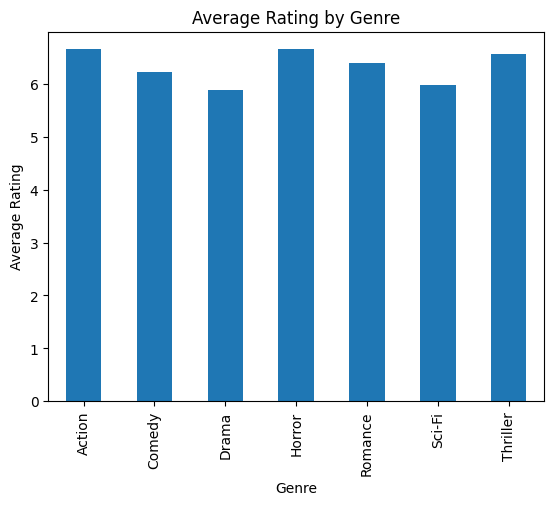

In [68]:
#1. Create a bar chart showing the average rating by genre.
import matplotlib.pyplot as plt 
average_rating_per_genre.plot(kind='bar', x='Genre', y='Rating', legend=False)
plt.title('Average Rating by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.show() 

Text(0, 0.5, 'Box Office (in millions)')

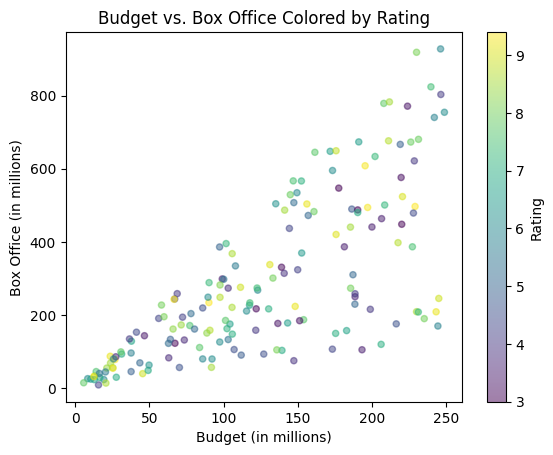

In [70]:
#2. Generate a scatter plot of Budget vs. Box Office, colored by Rating.
movies_data_from_csv.plot(kind='scatter', x='Budget', y='BoxOffice', c='Rating', colormap='viridis', alpha=0.5)
plt.title('Budget vs. Box Office Colored by Rating')
plt.xlabel('Budget (in millions)')
plt.ylabel('Box Office (in millions)')

Text(0.5, 0, 'Runtime (minutes)')

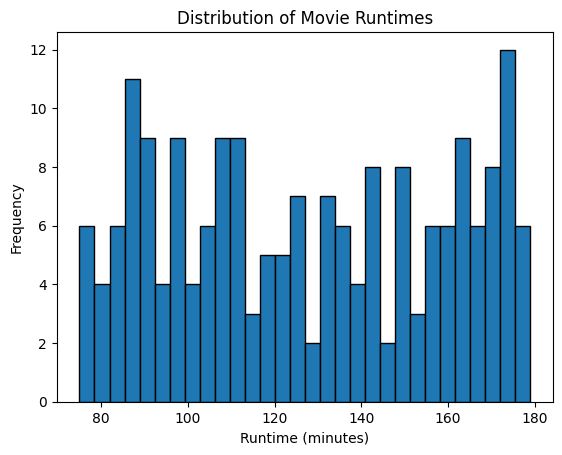

In [71]:
#3. Plot the distribution of movie runtimes using a histogram.
movies_data_from_csv['Runtime'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Distribution of Movie Runtimes')
plt.xlabel('Runtime (minutes)')

Text(0, 0.5, 'ROI')

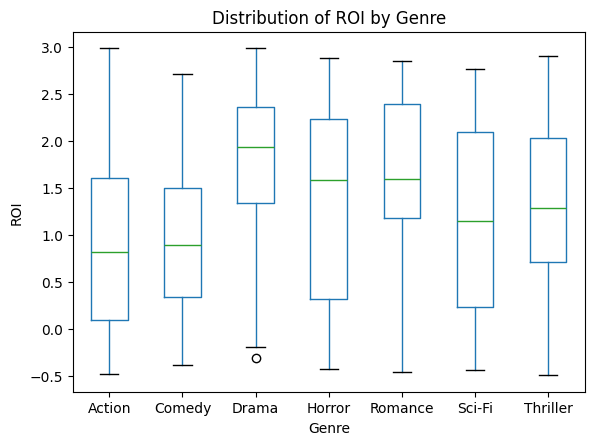

In [72]:
#4. Create a box plot showing the distribution of ROI by genre.
movies_data_from_csv.boxplot(column='ROI1', by='Genre', grid=False)
plt.title('Distribution of ROI by Genre')
plt.suptitle('')
plt.xlabel('Genre')
plt.ylabel('ROI')

Text(0.5, 0, 'Year')

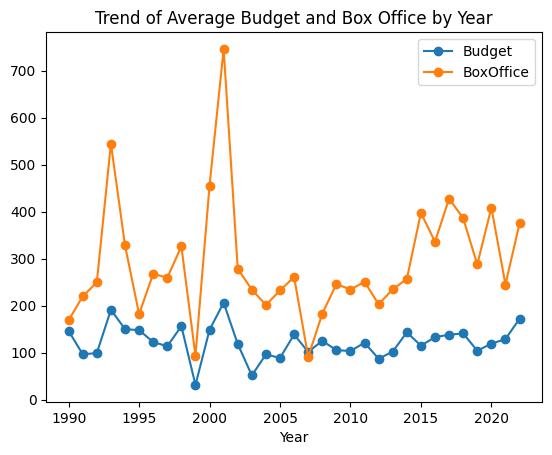

In [73]:
#5. Generate a line plot showing the trend of average budget and box office by year.   
average_budget_boxoffice_per_year = movies_data_from_csv.groupby('Year')[['Budget', 'BoxOffice']].mean().reset_index()
average_budget_boxoffice_per_year.plot(x='Year', y=['Budget', 'BoxOffice'], kind='line', marker='o')
plt.title('Trend of Average Budget and Box Office by Year')
plt.xlabel('Year')